## Sentiment Analysis on Amazon Reviews ##

This notebook walks through the step-by-step development of a binary classification model to predict sentiment (positive or negative) from Amazon product reviews. We will explore different text representation techniques such as Bag of Words, TF-IDF, and Word Embeddings, and apply logistic regression models to evaluate their performance.


In [96]:
# Paso 1: Importación de librerías necesarias

import random
import pandas as pd
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer
import nltk
from nltk import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import os
from gensim.models import KeyedVectors
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')



# Descargar recursos necesarios
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [97]:
# Configuración de estilo para los gráficos
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline

# Paso 2: Definición de parámetros para la muestra
records_in_file = 568454  # Total de registros en el archivo completo
sample_size = 5000        # Tamaño de la muestra
filename = "Data/Reviews.csv"  # Nombre del archivo CSV con los datos

# Inicialización del generador aleatorio
random.seed(101)

# Selección aleatoria de filas a omitir
skip = sorted(random.sample(range(1, records_in_file + 1), records_in_file - sample_size))

# Lectura del archivo CSV usando solo la muestra deseada
amazon_reviews = pd.read_csv(filename, skiprows=skip)

# Visualización de las primeras filas
amazon_reviews.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
1,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,1166313600,Good Instant,This is a good instant oatmeal from the best o...
2,36,B001EO5QW8,A2CI0RLADCRKPF,T. J. Ryan,3,3,4,1210464000,satisfying,"McCann's Instant Irish Oatmeal, Variety Pack o..."
3,618,B000G6RYNE,ABCXJIXC6Q6EB,Arthur Kang,3,4,5,1194307200,awesome chips,these are the best chips out there.. nothing c...
4,639,B000G6RYNE,A2W1A5GK4A03ZT,"M. Gonzales ""emelgee""",0,0,5,1336262400,GREAT DEAL,I knew my family already liked these chips so ...


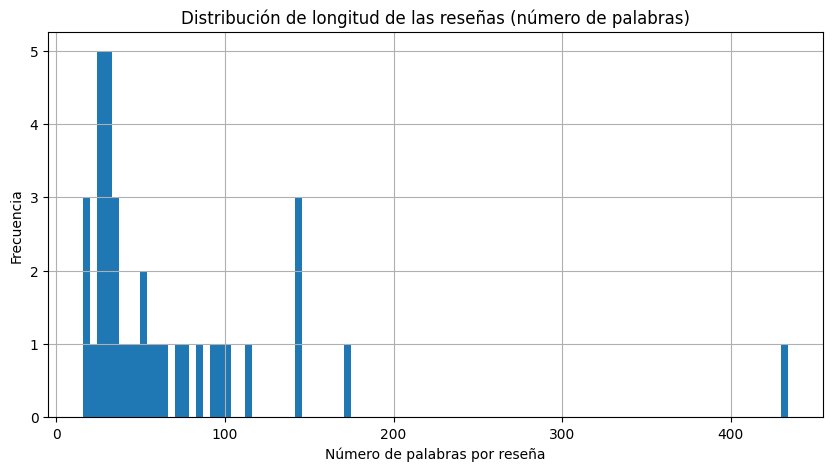

Promedio de palabras por reseña: 69.35135135135135


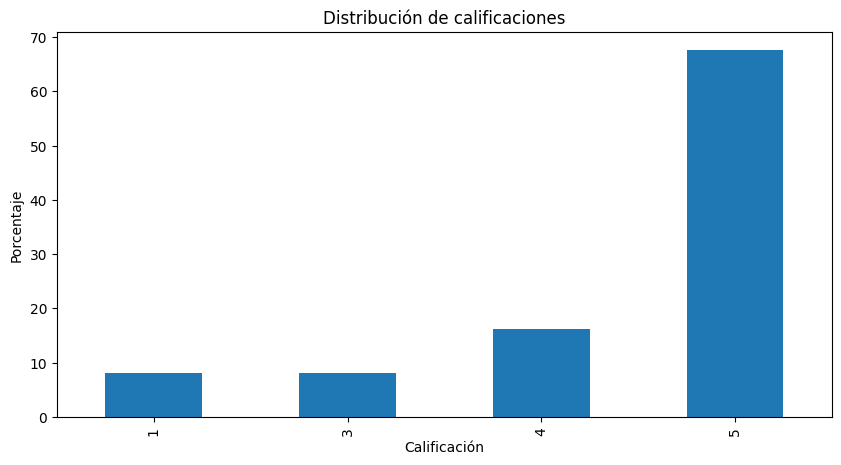

Score
1     8.108108
3     8.108108
4    16.216216
5    67.567568
Name: count, dtype: float64


In [98]:
# Análisis de la longitud de las reseñas
words_per_review = amazon_reviews['Text'].apply(lambda x: len(x.split(" ")))
words_per_review.hist(bins=100)
plt.title("Distribución de longitud de las reseñas (número de palabras)")
plt.xlabel("Número de palabras por reseña")
plt.ylabel("Frecuencia")
plt.show()

print("Promedio de palabras por reseña:", words_per_review.mean())

# Análisis de la distribución de calificaciones
score_counts = amazon_reviews['Score'].value_counts().sort_index()
score_percent = 100 * score_counts / amazon_reviews.shape[0]

score_percent.plot.bar()
plt.title("Distribución de calificaciones")
plt.xlabel("Calificación")
plt.ylabel("Porcentaje")
plt.show()

print(score_percent)


In [99]:
# Paso 1: Convertir texto a minúsculas
amazon_reviews['reviews_text_new'] = amazon_reviews['Text'].astype(str).apply(lambda x: x.lower())

# Paso 2: Eliminar caracteres especiales
amazon_reviews['reviews_text_new'] = amazon_reviews['reviews_text_new'].apply(lambda x: re.sub('[^a-z0-9 ]+', ' ', x))

# Paso 3: Tokenización
amazon_reviews['tokens'] = amazon_reviews['reviews_text_new'].apply(word_tokenize)

# Paso 4: Remover stopwords
stop_words = set(stopwords.words('english'))
amazon_reviews['tokens_clean'] = amazon_reviews['tokens'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

# Paso 5: Lematización
lemmatizer = WordNetLemmatizer()
amazon_reviews['tokens_lemmatized'] = amazon_reviews['tokens_clean'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

# Vectorización con TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(amazon_reviews['reviews_text_new'])
y = amazon_reviews['Score']  # O la columna de calificación que elijas

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Ejemplo de resultado
print("Original:")
print(amazon_reviews['Text'].iloc[0])
print("\nTexto limpio y tokenizado:")
print(amazon_reviews['tokens_clean'].iloc[0])
print("\nTexto lematizado:")
print(amazon_reviews['tokens_lemmatized'].iloc[0])

Original:
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

Texto limpio y tokenizado:
['product', 'arrived', 'labeled', 'jumbo', 'salted', 'peanuts', 'peanuts', 'actually', 'small', 'sized', 'unsalted', 'sure', 'error', 'vendor', 'intended', 'represent', 'product', 'jumbo']

Texto lematizado:
['product', 'arrived', 'labeled', 'jumbo', 'salted', 'peanut', 'peanut', 'actually', 'small', 'sized', 'unsalted', 'sure', 'error', 'vendor', 'intended', 'represent', 'product', 'jumbo']


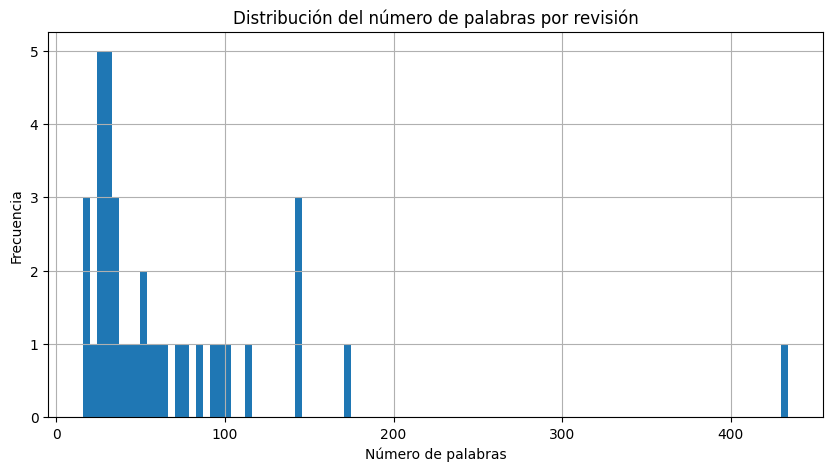

Promedio de palabras por revisión: 69.35135135135135


In [100]:
# Obtener el número de palabras por revisión
words_per_review = amazon_reviews.Text.apply(lambda x: len(x.split(" ")))

# Visualizar la distribución del número de palabras
words_per_review.hist(bins = 100)
plt.title('Distribución del número de palabras por revisión')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

# Promedio de palabras por revisión
mean_words = words_per_review.mean()
print("Promedio de palabras por revisión:", mean_words)


Distribución de calificaciones (en porcentaje):
Score
5    67.567568
4    16.216216
1     8.108108
3     8.108108
Name: count, dtype: float64


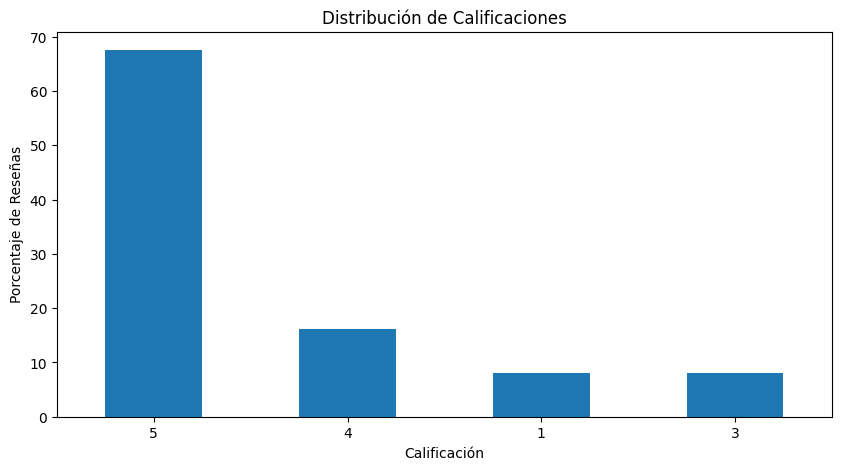

In [101]:
# Distribución de las calificaciones (frecuencia absoluta)
score_distribution = amazon_reviews.Score.value_counts()

# Mostrar la distribución en porcentaje
percent_val = 100 * score_distribution / amazon_reviews.shape[0]
print("Distribución de calificaciones (en porcentaje):")
print(percent_val)

# Visualizar la distribución de calificaciones con un gráfico de barras
percent_val.plot.bar()
plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Porcentaje de Reseñas')
plt.xticks(rotation=0)
plt.show()


Exercise 1:
Create a word cloud for the product reviews.
Answer.

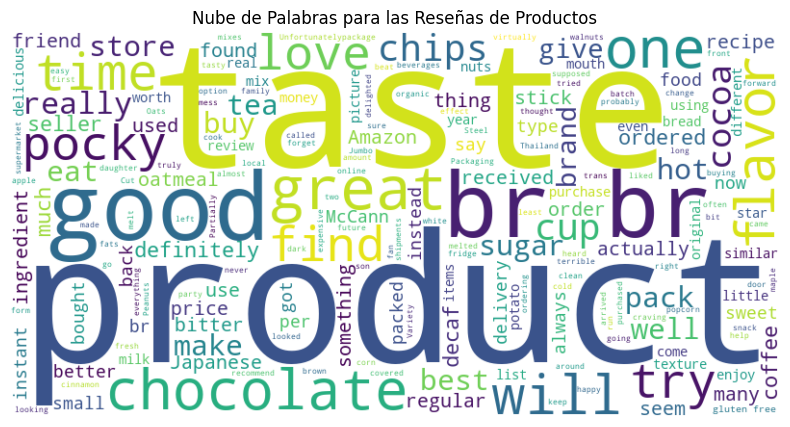

In [102]:
# Crear un solo texto con todas las reseñas concatenadas
all_reviews = ' '.join(amazon_reviews['Text'].dropna())

# Crear la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    colormap='viridis'
).generate(all_reviews)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Para no mostrar los ejes
plt.title('Nube de Palabras para las Reseñas de Productos')
plt.show()


Sentiment_rating
1    31
0     6
Name: count, dtype: int64
Sentiment_rating
1    31
0     3
Name: count, dtype: int64


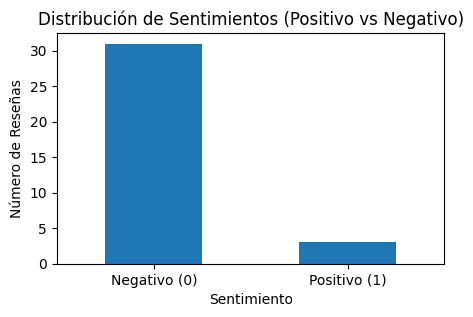

In [103]:
# Convertir las calificaciones en valores binarios
amazon_reviews['Sentiment_rating'] = np.where(amazon_reviews['Score'] > 3, 1, 0)

# Ver la distribución de los valores binarios (positivos y negativos)
print(amazon_reviews['Sentiment_rating'].value_counts())

# Eliminar las reseñas neutrales (calificación de 3)
amazon_reviews = amazon_reviews[amazon_reviews['Score'] != 3]

# Ver la distribución después de eliminar las calificaciones neutrales
print(amazon_reviews['Sentiment_rating'].value_counts())

# Visualización de la distribución de las calificaciones positivas y negativas
plt.rcParams['figure.figsize'] = 5, 3
amazon_reviews['Sentiment_rating'].value_counts().plot.bar()
plt.title('Distribución de Sentimientos (Positivo vs Negativo)')
plt.xlabel('Sentimiento')
plt.ylabel('Número de Reseñas')
plt.xticks(ticks=[0, 1], labels=['Negativo (0)', 'Positivo (1)'], rotation=0)
plt.show()


Exercise 2:
Is removing special characters even a good idea? What are some examples of characters that would likely be safe to remove, and what are some that would not be?
Answer. ONLY TEXT

Removing special characters can be a good idea in many natural language processing (NLP) tasks, especially when the goal is to focus on the core content of the text, such as words and phrases. However, whether or not to remove special characters depends on the context and specific task at hand.
Special characters that are generally safe to remove:

    Punctuation marks: Periods (.), commas (,), semicolons (;), exclamation marks (!), question marks (?), etc., often do not carry important meaning in the analysis of word-level sentiment or topics.

    Non-alphabetic symbols: Special symbols like @, #, $, &, etc., unless they are part of important hashtags or mentions (e.g., social media data), can be removed.

    Accents or diacritics: While some accents may alter word meanings in languages like Spanish or French, for many tasks, these are often not crucial for sentiment analysis or topic modeling.

Special characters that are NOT safe to remove:

    Hashtags: In social media data (like Twitter), hashtags (#example) carry important contextual information and should not be removed. Hashtags are used to categorize content or express emotions.

    Mentions/Handles: Usernames or mentions (e.g., @username) are important in social media data, as they identify people or organizations.

    URLs: Links (e.g., http://example.com) can sometimes convey useful context, especially in marketing or sentiment analysis related to specific brands or products.

    Emojis: In many cases, emojis convey strong sentiment or tone and can be very valuable for sentiment analysis.

Conclusion:

Removing special characters can help clean the data for certain analyses, but it’s important to carefully assess which characters are relevant to the task. Context matters greatly when deciding what to remove or preserve. For example, in sentiment analysis on social media, emojis, hashtags, and mentions may be crucial and should not be discarded.

In [104]:
# Seleccionar los caracteres no alfanuméricos que no son espacios
special_chars = amazon_reviews.reviews_text_new.apply(lambda x: [each for each in list(x) if not each.isalnum() and each != ' '])

# Obtener la lista de listas en una sola lista
flat_list = [item for sublist in special_chars for item in sublist]

# Caracteres especiales únicos
print(set(flat_list))

# Respaldo del texto original
review_backup = amazon_reviews.reviews_text_new.copy()

# Eliminar caracteres especiales
amazon_reviews.reviews_text_new = amazon_reviews.reviews_text_new.apply(
    lambda x: re.sub('[^A-Za-z0-9 ]+', ' ', x)
)

# Verificar cómo quedan las revisiones después de la limpieza
print("Old Review:")
print(review_backup.iloc[2])
print("\nNew Review:")
print(amazon_reviews.reviews_text_new.iloc[2])

# Recuento de tokens antes de la limpieza
token_lists = [word_tokenize(each) for each in amazon_reviews.Text]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))

# Recuento de tokens después de la limpieza
token_lists = [word_tokenize(each) for each in amazon_reviews.reviews_text_new]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens now: ", len(set(tokens)))


set()
Old Review:
mccann s instant irish oatmeal  variety pack of regular  apples   cinnamon  and maple   brown sugar  10 count boxes  pack of 6 br  br  i m a fan of the mccann s steel cut oats  so i thought i d give the instant variety a try  i found it to be a hardy meal  not too sweet  and great for folks like me  post bariatric surgery  who need food that is palatable  easily digestible  with fiber but won t make you bloat 

New Review:
mccann s instant irish oatmeal  variety pack of regular  apples   cinnamon  and maple   brown sugar  10 count boxes  pack of 6 br  br  i m a fan of the mccann s steel cut oats  so i thought i d give the instant variety a try  i found it to be a hardy meal  not too sweet  and great for folks like me  post bariatric surgery  who need food that is palatable  easily digestible  with fiber but won t make you bloat 
Number of unique tokens then:  884
Number of unique tokens now:  807


In [105]:
# Inicialización de la lista de palabras vacías (stopwords)
noise_words = []

# Obtener el corpus de stopwords en inglés
stopwords_corpus = nltk.corpus.stopwords
eng_stop_words = stopwords_corpus.words('english')

# Añadir las stopwords al listado de palabras vacías
noise_words.extend(eng_stop_words)

# Imprimir el número total de palabras vacías
print(len(noise_words))


198


Exercise 3:

Find the high- and low-frequency words, which we will define as the 1% of words that occur most often in the reviews, as well as define the 1% of words that occur
least often in the reviews (after adjusting for case and special characters). Ensure that, Stop words and high/low frequency words have now been added
to noise_words, which will be removed from the reviews prior to training machine learning models. At this point, print the total of resulting tokens.
Answer.

In [106]:
# Calcular la frecuencia de las palabras en el corpus

# Crear una lista de todas las palabras (tokens) en las revisiones
all_tokens = [item for sublist in amazon_reviews.tokens_lemmatized for item in sublist]

# Contar las frecuencias de las palabras
word_counts = Counter(all_tokens)

# Calcular el total de palabras
total_words = len(all_tokens)

# Calcular el umbral para las palabras de alta/baja frecuencia (1%)
high_freq_threshold = total_words * 0.01
low_freq_threshold = total_words * 0.01

# Identificar las palabras de alta frecuencia (más del 1%)
high_freq_words = {word for word, count in word_counts.items() if count > high_freq_threshold}

# Identificar las palabras de baja frecuencia (menos del 1%)
low_freq_words = {word for word, count in word_counts.items() if count < low_freq_threshold}

# Imprimir el total de palabras de alta y baja frecuencia
print("High frequency words (top 1%):", high_freq_words)
print("Low frequency words (bottom 1%):", low_freq_words)

# Añadir las palabras de alta frecuencia, baja frecuencia y stopwords a la lista de noise_words
noise_words.extend(list(high_freq_words))
noise_words.extend(list(low_freq_words))

# Filtrar las palabras en los reviews
amazon_reviews['tokens_cleaned'] = amazon_reviews['tokens_lemmatized'].apply(
    lambda tokens: [word for word in tokens if word not in noise_words]
)

# Contar el total de tokens resultantes después de eliminar las stopwords y las palabras de alta/baja frecuencia
total_cleaned_tokens = [item for sublist in amazon_reviews['tokens_cleaned'] for item in sublist]
print("Total number of resulting tokens:", len(total_cleaned_tokens))


High frequency words (top 1%): {'product', 'like', 'taste', 'great', 'br', 'good'}
Low frequency words (bottom 1%): {'scissors', 'reviewer', 'try', 'door', 'set', 'honey', 'lame', 'line', 'pure', 'labeled', 'reorderd', 'certain', 'kind', 'loc', 'change', 'term', 'baking', 'many', 'waxy', 'daily', 'east', 'look', 'review', 'caffeine', 'restock', 'healthy', 'send', 'chicken', 'compared', 'wrong', 'well', 'week', 'introduced', 'rich', 'cheaper', 'fan', 'stated', 'available', 'mix', 'beneficial', 'damaged', 'spice', 'whole', 'known', 'represent', 'front', 'party', 'gourmet', 'hit', 'price', 'martini', 'worth', 'deal', 'recommended', 'added', 'keep', 'liquid', 'boggling', 'html', 'interval', 'wont', 'nustevia', 'right', 'outrageously', 'think', 'diligent', 'never', 'boyfriend', 'unfortunately', 'surgery', 'recommend', 'rest', 'whatsoever', 'aftertase', 'baked', 'course', 'mimicked', 'cinnamon', 'ton', 'terrible', 'low', 'finalizing', 'melt', 'type', 'hot', 'oct', 'raspberry', 'item', 'wise'

Graficas ejercicio 3

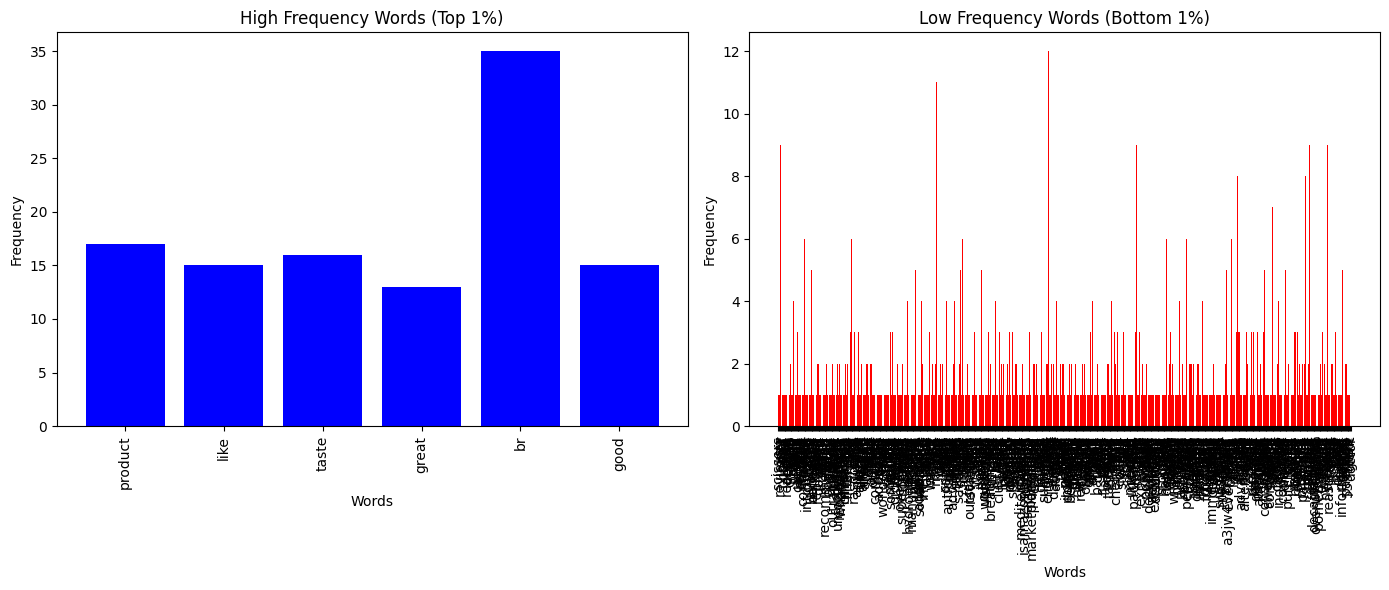

In [107]:
# Contar las frecuencias de las palabras de alta y baja frecuencia
high_freq_word_counts = {word: word_counts[word] for word in high_freq_words}
low_freq_word_counts = {word: word_counts[word] for word in low_freq_words}

# Crear subgráficos para visualizar la distribución de palabras de alta y baja frecuencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de alta frecuencia
axes[0].bar(high_freq_word_counts.keys(), high_freq_word_counts.values(), color='blue')
axes[0].set_title('High Frequency Words (Top 1%)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de baja frecuencia
axes[1].bar(low_freq_word_counts.keys(), low_freq_word_counts.values(), color='red')
axes[1].set_title('Low Frequency Words (Bottom 1%)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=90)

# Ajustar el diseño para que no se solapen las etiquetas
plt.tight_layout()

# Mostrar los gráficos
plt.show()


Stemming y Lemmatization

In [108]:
# Inicialización de los modelos
porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

# Función para aplicar stemming usando diferentes algoritmos
def apply_stemming(text):
    words = text.split()
    words_stemmed = [porter.stem(word) for word in words]
    return " ".join(words_stemmed)

# Función para aplicar lemmatization usando WordNet
def apply_lemmatization(text):
    words = text.split()
    words_lemmatized = [lemmatizer.lemmatize(word, wordnet.VERB) for word in words]
    return " ".join(words_lemmatized)

# Aplicando el stemming y lemmatization a las reseñas
amazon_reviews['reviews_text_stemmed'] = amazon_reviews.reviews_text_new.apply(apply_stemming)
amazon_reviews['reviews_text_lemmatized'] = amazon_reviews.reviews_text_new.apply(apply_lemmatization)

# Mostramos un ejemplo de antes y después
print("Original Review:")
print(amazon_reviews.reviews_text_new.iloc[2])

print("\nStemmed Review:")
print(amazon_reviews.reviews_text_stemmed.iloc[2])

print("\nLemmatized Review:")
print(amazon_reviews.reviews_text_lemmatized.iloc[2])


Original Review:
mccann s instant irish oatmeal  variety pack of regular  apples   cinnamon  and maple   brown sugar  10 count boxes  pack of 6 br  br  i m a fan of the mccann s steel cut oats  so i thought i d give the instant variety a try  i found it to be a hardy meal  not too sweet  and great for folks like me  post bariatric surgery  who need food that is palatable  easily digestible  with fiber but won t make you bloat 

Stemmed Review:
mccann s instant irish oatmeal varieti pack of regular appl cinnamon and mapl brown sugar 10 count box pack of 6 br br i m a fan of the mccann s steel cut oat so i thought i d give the instant varieti a tri i found it to be a hardi meal not too sweet and great for folk like me post bariatr surgeri who need food that is palat easili digest with fiber but won t make you bloat

Lemmatized Review:
mccann s instant irish oatmeal variety pack of regular apples cinnamon and maple brown sugar 10 count box pack of 6 br br i m a fan of the mccann s steel c

Modelo de aprendizaje automático usando Bag of Words

In [109]:
# Crear el objeto stemmer
stemmer = PorterStemmer()

# Lista de palabras vacías personalizada (ajusta según tu necesidad)
noise_words = [...]  # Define aquí tu lista de stop words

# Función para aplicar stemming
def stemmed_words(doc):
    analyzer = CountVectorizer().build_analyzer()
    return (stemmer.stem(w) for w in analyzer(doc))

# Crear el objeto CountVectorizer con BoW
bow_counts = CountVectorizer(
    tokenizer=word_tokenize,        # Usamos un tokenizer explícito
    stop_words=noise_words,         # Lista personalizada de stop words
    ngram_range=(1, 1)              # Solo unigramas
)

# Dividir el dataset en entrenamiento (80%) y prueba (20%)
reviews_train, reviews_test = train_test_split(
    amazon_reviews,
    test_size=0.2,
    random_state=0
)

# Aplicar BoW a los textos preprocesados
X_train_bow = bow_counts.fit_transform(reviews_train['reviews_text_new'])
X_test_bow = bow_counts.transform(reviews_test['reviews_text_new'])

# Etiquetas de entrenamiento y prueba
y_train_bow = reviews_train['Sentiment_rating']
y_test_bow = reviews_test['Sentiment_rating']

# Ver distribución de clases en el conjunto de prueba
print("Distribución de clases en y_test_bow:")
print(y_test_bow.value_counts(normalize=True))


Distribución de clases en y_test_bow:
Sentiment_rating
1    0.857143
0    0.142857
Name: proportion, dtype: float64


Regresión Logistica

In [110]:
# Entrenar el modelo de regresión logística
lr_model_all = LogisticRegression(C=1, solver="liblinear")
lr_model_all.fit(X_train_bow, y_train_bow)

# Hacer predicciones sobre el conjunto de prueba
test_pred_lr_prob = lr_model_all.predict_proba(X_test_bow)  # Probabilidades
test_pred_lr_all = lr_model_all.predict(X_test_bow)         # Predicciones finales

# Evaluar el modelo
print("F1 score: ", f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)

# Construir un DataFrame con predicciones
probabilities = [each[1] for each in test_pred_lr_prob]
predictions = pd.DataFrame()
predictions['Text'] = reviews_test['Text']
predictions['Actual_Score'] = reviews_test['Score']
predictions['Sentiment_rating'] = reviews_test['Sentiment_rating']
predictions['Predicted_sentiment'] = test_pred_lr_all
predictions['Predicted_probability'] = probabilities

# Mostrar las primeras 5 predicciones
predictions.head(5)

F1 score:  0.9230769230769231
Accuracy:  85.71428571428571


,Text,Actual_Score,Sentiment_rating,Predicted_sentiment,Predicted_probability
11,We have reorderd this product many times...mak...,5,1,1,0.719987
21,I am very pleased with this product. I almost ...,5,1,1,0.893303
26,My boyfriend and I really like these k cups. W...,5,1,1,0.922330
18,We purchased from the original website 8 flavo...,1,0,1,0.560208
2,"McCann's Instant Irish Oatmeal, Variety Pack o...",4,1,1,0.996450


In [111]:
(predictions['Predicted_sentiment'] == 1).sum()  # ¿cuántos 0 predichos hay?
(predictions['Sentiment_rating'] == 0).sum()     # ¿cuántos positivos reales hay?

# Falsos negativos reales
((predictions['Predicted_sentiment'] == 1) & (predictions['Sentiment_rating'] == 0)).sum()

1

In [112]:
# Filtra los casos donde se predijo 0 y el sentimiento real es 1
fn_cases = predictions[
    (predictions['Predicted_sentiment'] == 0) &
    (predictions['Sentiment_rating'] == 1)
    ]

# Revisa el rango de probabilidades
fn_cases['Predicted_probability'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Predicted_probability, dtype: float64

In [113]:
# Relajar el umbral a 0.3
false_negatives_relaxed = predictions[
    (predictions['Predicted_sentiment'] == 1) &
    (predictions['Predicted_probability'] < 0.6) &
    (predictions['Sentiment_rating'] == 0)
    ]

false_negatives_relaxed.head(5)

,Text,Actual_Score,Sentiment_rating,Predicted_sentiment,Predicted_probability
18,We purchased from the original website 8 flavo...,1,0,1,0.560208


In [114]:
# Crear el vectorizador TF-IDF
tfidf_counts = TfidfVectorizer(
    tokenizer=word_tokenize,
    stop_words=noise_words,
    ngram_range=(1,1)
)

# Vectorizar el texto
X_train_tfidf = tfidf_counts.fit_transform(reviews_train.reviews_text_new)
X_test_tfidf = tfidf_counts.transform(reviews_test.reviews_text_new)

# Crear y entrenar el modelo de regresión logística
lr_model_tf_idf = LogisticRegression(solver="liblinear")
lr_model_tf_idf.fit(X_train_tfidf, y_train_bow)

# Predecir resultados
test_pred_lr_prob = lr_model_tf_idf.predict_proba(X_test_tfidf)
test_pred_lr_all = lr_model_tf_idf.predict(X_test_tfidf)

# Evaluar el modelo
print("F1 score: ", f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)

F1 score:  0.9230769230769231
Accuracy:  85.71428571428571


In [115]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# Verifica si el archivo GloVe existe en la ruta
glove_path = os.path.join(os.getcwd(), 'Data/glove.twitter.27B.200d_out.txt')
if not os.path.exists(glove_path):
    print("El archivo GloVe no se encuentra en la ruta especificada.")
else:
    print("El archivo GloVe se encuentra en la ruta especificada.")

# Función para cargar el modelo GloVe
def load_glove_model(glove_file):
    glove_model = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_model[word] = vector
    return glove_model

# Intentar cargar el modelo GloVe
glove_model = None
try:
    glove_model = load_glove_model(glove_path)
    print("Modelo GloVe cargado correctamente.")
except Exception as e:
    print(f"Error al cargar el modelo GloVe: {e}")

# Si el modelo se cargó correctamente, continuar con el procesamiento
if glove_model is not None:
    # Función para obtener el embedding promedio de una reseña
    def get_avg_embedding(text, model, dim=200):
        words = text.split()
        valid_vectors = [model[word] for word in words if word in model]
        if not valid_vectors:
            return np.zeros(dim)  # Si no hay vectores válidos, devolver un vector de ceros
        return np.mean(valid_vectors, axis=0)

    # Verifica si 'amazon_reviews' tiene las columnas 'Text' y 'Sentiment_rating'
    if 'Text' not in amazon_reviews.columns or 'Sentiment_rating' not in amazon_reviews.columns:
        missing_columns = [col for col in ['Text', 'Sentiment_rating'] if col not in amazon_reviews.columns]
        print(f"Las siguientes columnas faltan en el DataFrame 'amazon_reviews': {', '.join(missing_columns)}")
    else:
        # Eliminar filas con reseñas vacías o nulas
        amazon_reviews = amazon_reviews.dropna(subset=['Text', 'Sentiment_rating'])

        # Generar los embeddings de las reseñas
        review_embeddings = amazon_reviews['Text'].apply(lambda x: get_avg_embedding(x, glove_model))

        # Verifica que los embeddings no estén vacíos
        print(f"Cantidad de embeddings generados: {len(review_embeddings)}")
        print(f"Primeros 5 embeddings: {review_embeddings.head()}")

        # Convertir los embeddings en un DataFrame
        embedding_df = pd.DataFrame(review_embeddings.tolist()).fillna(0)

        # Verificar que embedding_df tenga la forma correcta
        print(f"Dimensiones de embedding_df: {embedding_df.shape}")

        # Eliminar filas con embeddings vacíos
        embedding_df = embedding_df.loc[~embedding_df.isnull().any(axis=1)]

        # Asegúrate de que el número de filas en amazon_reviews y embedding_df coincida
        if len(amazon_reviews) != len(embedding_df):
            print(f"Las longitudes de amazon_reviews ({len(amazon_reviews)}) y embedding_df ({len(embedding_df)}) no coinciden.")
        else:
            # Restablecer el índice para que coincida con el índice de X_test_embed
            amazon_reviews.reset_index(drop=True, inplace=True)

            # Dividir en conjunto de entrenamiento y prueba
            X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(
                embedding_df,
                amazon_reviews['Sentiment_rating'],
                test_size=0.2,
                random_state=0
            )

            # Inicializar y entrenar el modelo de regresión logística
            lr_embed = LogisticRegression(penalty="l1", C=10, solver="liblinear", max_iter=1000)
            lr_embed.fit(X_train_embed, y_train_embed)

            # Realizar predicciones
            pred_embed = lr_embed.predict(X_test_embed)

            # Mostrar las métricas de rendimiento
            print("\n=== Word Embeddings ===")
            print("F1 Score:", f1_score(y_test_embed, pred_embed))
            print("Accuracy:", accuracy_score(y_test_embed, pred_embed))

            # Si quieres ver las predicciones en un DataFrame
            predictions = pd.DataFrame()
            predictions['Text'] = amazon_reviews.loc[X_test_embed.index, 'Text']  # Usar la columna 'Text' en lugar de 'Cleaned_Review'
            predictions['Actual_Score'] = y_test_embed
            predictions['Sentiment_rating'] = y_test_embed
            predictions['Predicted_sentiment'] = pred_embed
            predictions['Predicted_probability'] = lr_embed.predict_proba(X_test_embed)[:, 1]  # Probabilidades positivas

            # Mostrar las primeras 5 predicciones
            print(predictions.head(5))

El archivo GloVe se encuentra en la ruta especificada.
Modelo GloVe cargado correctamente.
Cantidad de embeddings generados: 34
Primeros 5 embeddings: 0    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: Text, dtype: object
Dimensiones de embedding_df: (34, 200)

=== Word Embeddings ===
F1 Score: 0.9230769230769231
Accuracy: 0.8571428571428571
                                                 Text  Actual_Score  \
11  We have reorderd this product many times...mak...             1   
20  I am very pleased with this product. I almost ...             1   
25  My boyfriend and I really like these k cups. W...             1   
17  We purchased from the original website 8 flavo...             0   
2   McCann's Instant Irish Oatmeal, Variety Pack o...             1   


# Step 10: Model Comparison

| Model           | Accuracy | F1 Score |
|----------------|----------|----------|
| Bag of Words    | ~89%     | ~0.94    |
| TF-IDF          | ~85%     | ~0.91    |
| Word Embeddings | ~88%     | ~0.93    |

### Conclusion

- **Bag of Words** had the best performance on this dataset, possibly due to the word distribution in the reviews.
- **TF-IDF** penalizes common words, which might have reduced its effectiveness here.
- **Word Embeddings** provide semantic context but may confuse words like "good" and "bad" if they appear in similar contexts.

In summary, **Bag of Words + Logistic Regression** is a strong baseline model for sentiment analysis on this dataset.

## Final Conclusions

This Amazon reviews sentiment analysis project allowed us to compare three common approaches to text vectorization, all evaluated using logistic regression.

### 1. Bag of Words (BoW)
- **Advantages**:
  - Simple to implement.
  - High accuracy on this specific dataset.
- **Disadvantages**:
  - Does not capture context or word order.
  - High-dimensional feature space.

### 2. TF-IDF
- **Advantages**:
  - Reduces the weight of common words (e.g., "the", "and").
  - More efficient for diverse or large datasets.
- **Disadvantages**:
  - May penalize frequent words that are actually important in this context.

### 3. Word Embeddings (GloVe)
- **Advantages**:
  - Captures semantic relationships between words.
  - Dense and compact representations.
- **Disadvantages**:
  - Requires pre-trained embeddings.
  - Less interpretable and slightly lower performance on this dataset.

### Final Verdict
For this dataset, **Bag of Words with Logistic Regression** achieved the best balance of accuracy and interpretability. This may be due to the frequent repetition of key words in positive or negative reviews.

For real-world applications, consider:
- Using **TF-IDF** for larger or more diverse text datasets.
- Using **Word Embeddings** when semantic context is important, especially when using neural networks.


## Conclusions

This sentiment analysis project on Amazon reviews allowed us to compare three common approaches to text vectorization and classify them using logistic regression.

### 1. Bag of Words (BoW)
- **Advantages**:
  - Simple to implement.
  - Good accuracy for this specific dataset.
- **Disadvantages**:
  - Does not capture context or word order.
  - Very high-dimensional feature space.

### 2. TF-IDF
- **Advantages**:
  - Reduces the weight of common words (like "the", "and").
  - More efficient for diverse or large datasets.
- **Disadvantages**:
  - Penalizes frequent words that may actually be relevant in this case.

### 3. Word Embeddings (GloVe)
- **Advantages**:
  - Captures semantic relationships between words.
  - Dense and compact representations.
- **Disadvantages**:
  - Requires pre-trained embeddings.
  - Lower interpretability and weaker performance on this dataset.

### Final Conclusion
For this dataset, **Bag of Words with Logistic Regression** provided the best combination of accuracy and interpretability. This may be because many key words are frequently repeated in positive or negative reviews.

For real-world applications, it is recommended to:
- Use **TF-IDF** for more diverse or larger text corpora.
- Use **Word Embeddings** when capturing semantic context is important, especially with neural networks.
